In [205]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

from contextlib import nullcontext

from datetime import datetime

from matplotlib import colormaps

In [206]:
api = wandb.Api()

In [207]:
EXPERIMENT_GROUP = "./artifacts/2024-02-s19/experiments/3-imagenet-butterfly"

In [208]:
def read_data(
    teacher,
    student,
    dataset,
    policy,
    lambda_task,
    lambda_kd,
    training_size,
    contamination_level,
    verbose=False,
    
):
    use_val_split=False,

    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-s19',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.dataset": dataset}
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    datasets = []
    for run in runs:
        seed = run.config["seed"]
        
        if not "arr_metrics"in run.summary:
            print(">> bad run config")
            print(run.config)
            count += 1
            return run
            continue
                                 
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        datasets.append(run.config["dataset"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                # remark: this is the actual value used in distillation
                # cf. https://github.com/p16i/xai-kd/blob/2023-09-s14--1-teacher-training-script/scripts/distill-layerwise.py#L364
                lambda_layer=run.config["policy_lambda_layer"],
                val_acc=best_val_acc, 
                teacher_acc=run.summary["teacher_acc"],
                policy=run.config["policy"]
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
        
        
    df = df.groupby(by="policy").agg(
        {
            "val_acc": ["mean", "std", "count"],
#             "val_agreement": ["mean", "std", "count"],
#             "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        3
    )
    
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="imagenet-resnet18-tv",
    student="resnet18dims64-48-48-10",
    dataset="imagenet-butterfly",
    lambda_task=0.0,
    lambda_kd=1.0,
#     policy="basis-identity:pca--uncentered",
    policy="nothing",

    training_size=1.0,
    verbose=True,
    contamination_level=0.0,
)

summary

we have 3 runs
df.shape: (1, 5)


policy   val_acc                 teacher_acc
                mean       std count        mean
0  nothing  0.936667  0.006667     3    0.966667

# Introduction

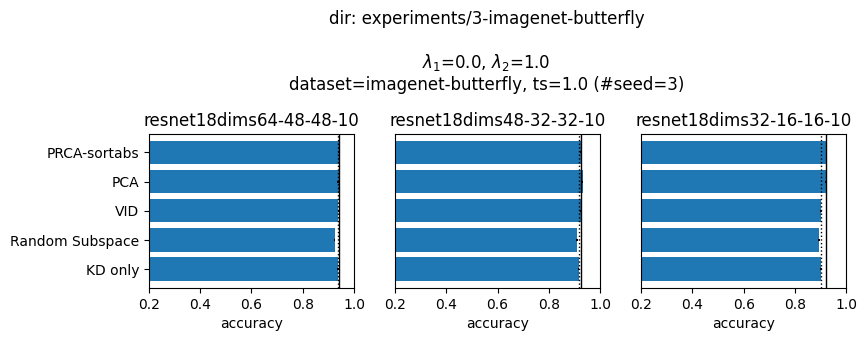

In [185]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def policy_alias(policy):
    _mapping = {
        "nothing": "KD only",
        "basis-identity:random--uncentered": "Random Subspace",
        "vid": "VID",
        "basis-identity:pca--uncentered": "PCA",
        "basis-identity:prca-sortabs--uncentered": "PRCA-sortabs",
    }
    
    return _mapping.get(policy, policy)

def layer_alias(layers):
    
    _mapping = {
        "layer1,layer2,layer3,layer4": "layer1,2,3,4",
        "layer2,layer3,layer4": "layer2,3,4",
        "layer3,layer4": "layer3,4",
        "layer4": "layer4",
    }
    
    return _mapping.get(layers, layers)

    
def viz_distillation(
    teacher, 
    training_size,
    dataset,
    arr_students,
    policies,
    show_legend=True, 
):
        

    lambda_kd = 1.0
    lambda_task = 0.0
    contamination_level = 0.0
            
    col = "val_acc"
    
    
    ncols = len(arr_students)
    nrows = 1
    
    plt.figure(figsize=(3*ncols, 2*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
        
    ticks = np.arange(len(policies))
    
    for six, student in enumerate(arr_students):
        
        stats = np.zeros(
            (len(policies), 2)
        )
        
        plt.subplot(nrows, ncols, six+1)
        plt.xlabel("accuracy")
        plt.title(student)
        plt.xlim([0.2, 1.0])
        
        df = read_data(
            teacher=teacher,
            student=student,
            dataset=dataset,
            policy="nothing",
            lambda_task=lambda_task,
            lambda_kd=lambda_kd,
            training_size=training_size,
            contamination_level=contamination_level,
            verbose=False
        )
        
        for pix, policy in enumerate(policies):


            df = read_data(
                teacher=teacher,
                student=student,
                dataset=dataset,

                policy=policy,
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,
                training_size=training_size,
                contamination_level=contamination_level,
                verbose=False
            )
            count = df["val_acc"]["count"].values[0]
            mean =   df["val_acc"]["mean"].values[0]
            stderr =   df["val_acc"]["std"].values[0] / (count ** 0.5)
            stats[pix, :] = mean, stderr
            
            if "prca" in policy or policy == "nothing":
                
                plt.axvline(
                    mean,
                    ls="-" if "prca" in policy else ":", 
                    lw=1, 
                    color="k"
                )

            
        plt.barh(
            ticks,
            stats[:, 0],
            xerr=stats[:, 1]
        )
        if six == 0:
            plt.yticks(
                ticks,
                map(lambda p: policy_alias(p), policies)
            )
        else:
            plt.yticks([])

    
    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
            ""
            f"dataset={dataset}, ts={training_size} (#seed={count})",
        ]),
        y=1.5,
    )
    
#     plt.subplots_adjust(hspace=0.5, wspace=0.1)


viz_distillation(
    teacher = "imagenet-resnet18-tv",
    training_size=1.0,
    dataset="imagenet-butterfly",
    arr_students=[
        "resnet18dims64-48-48-10",
        "resnet18dims48-32-32-10",
        "resnet18dims32-16-16-10",
    ],
    policies = [ 
        "nothing",
        "basis-identity:random--uncentered",
        "vid",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
    ],
)

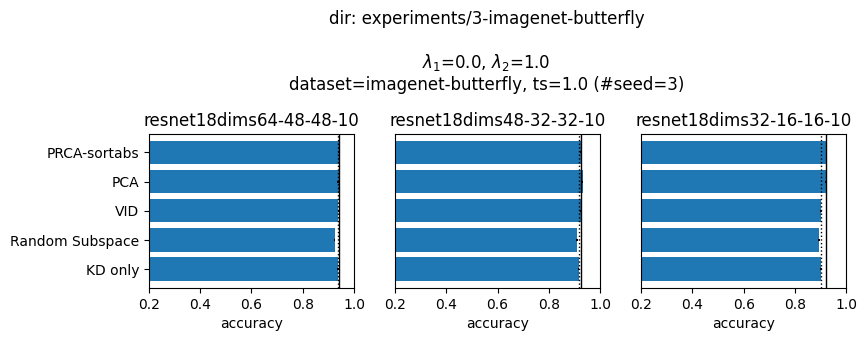

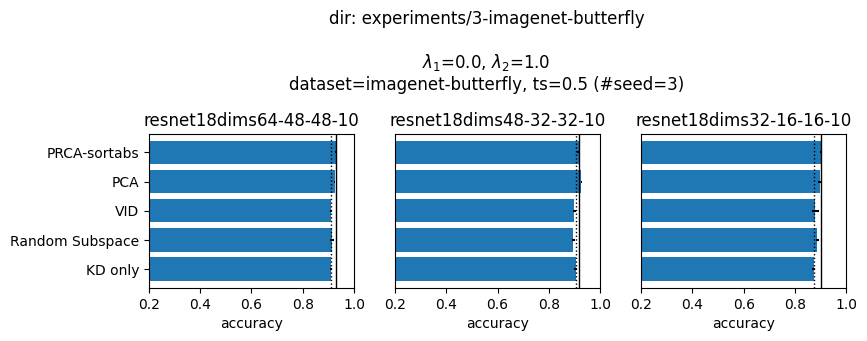

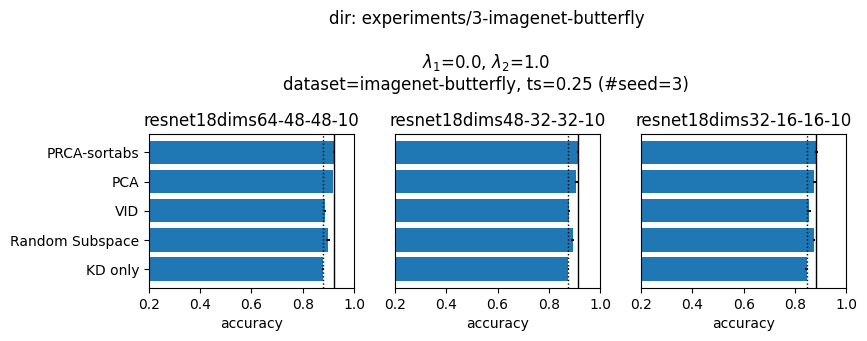

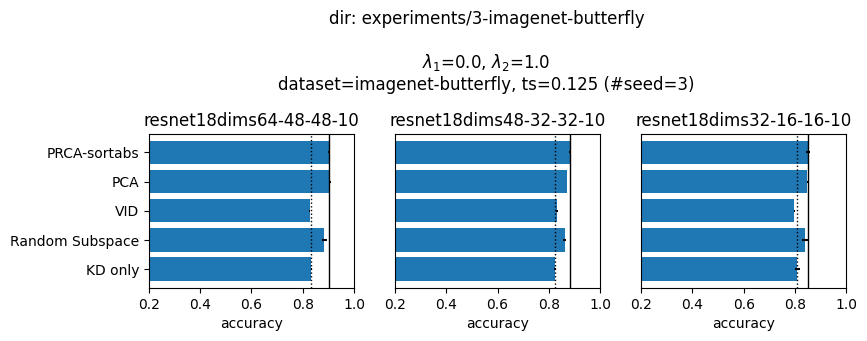

In [186]:
for training_size in [1.0, 0.5, 0.25, 0.125]:
    viz_distillation(
        teacher = "imagenet-resnet18-tv",
        training_size=training_size,
        dataset="imagenet-butterfly",

        arr_students=[
            "resnet18dims64-48-48-10",
            "resnet18dims48-32-32-10",
            "resnet18dims32-16-16-10",
        ],
        policies = [ 
            "nothing",
            "basis-identity:random--uncentered",
            "vid",
            "basis-identity:pca--uncentered",
            "basis-identity:prca-sortabs--uncentered",
        ],
    )


#### student=resnet18dims64-48-48-10 ####
> policy=                                 nothing: 0.9367(0.0038);0.9089(0.0040);0.8789(0.0040);0.8333(0.0019)
> policy=                                     vid: 0.9389(0.0029);0.9100(0.0033);0.8867(0.0051);0.8267(0.0019)
> policy=       basis-identity:random--uncentered: 0.9244(0.0029);0.9133(0.0084);0.8978(0.0073);0.8844(0.0106)
> policy=          basis-identity:pca--uncentered: 0.9400(0.0051);0.9244(0.0029);0.9178(0.0011);0.9056(0.0029)
> policy= basis-identity:prca-sortabs--uncentered: 0.9422(0.0029);0.9300(0.0038);0.9233(0.0038);0.9022(0.0029)

#### student=resnet18dims48-32-32-10 ####
> policy=                                 nothing: 0.9167(0.0019);0.9044(0.0048);0.8756(0.0029);0.8222(0.0040)
> policy=                                     vid: 0.9244(0.0022);0.8989(0.0059);0.8778(0.0040);0.8322(0.0048)
> policy=       basis-identity:random--uncentered: 0.9100(0.0051);0.8956(0.0059);0.8922(0.0048);0.8611(0.0068)
> policy=          basis-i

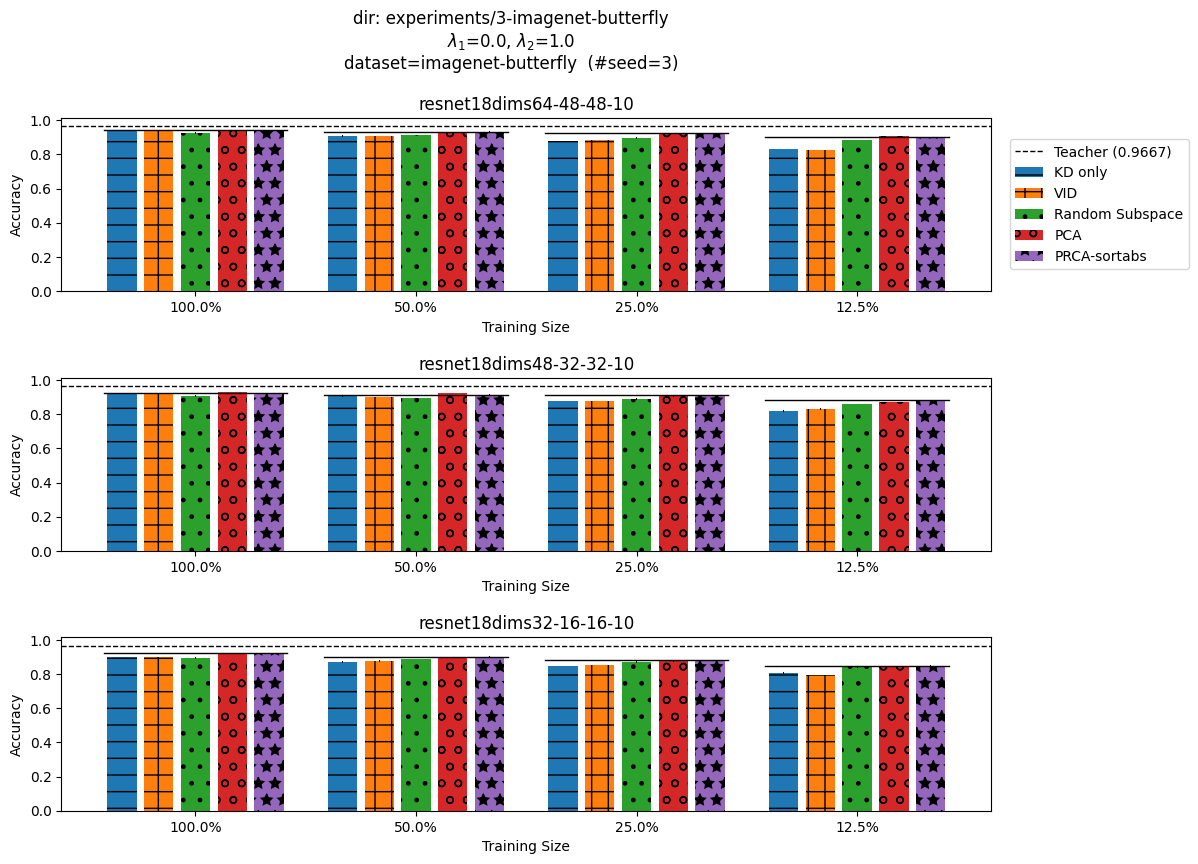

In [211]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def policy_alias(policy):
    _mapping = {
        "nothing": "KD only",
        "basis-identity:random--uncentered": "Random Subspace",
        "vid": "VID",
        "basis-identity:pca--uncentered": "PCA",
        "basis-identity:prca-sortabs--uncentered": "PRCA-sortabs",
    }
    
    return _mapping.get(policy, policy)

def layer_alias(layers):
    
    _mapping = {
        "layer1,layer2,layer3,layer4": "layer1,2,3,4",
        "layer2,layer3,layer4": "layer2,3,4",
        "layer3,layer4": "layer3,4",
        "layer4": "layer4",
    }
    
    return _mapping.get(layers, layers)

def bar_pattern(name):
    _mapping = {
        "nothing": "-",
        "vid": "+",
        "basis-identity:random--uncentered": ".",
        "basis-identity:pca--uncentered": "o",
        "basis-identity:prca-sortabs--uncentered": "*",
    }
    return _mapping[name]

    
def pretty_floats(mean, std):
    return ";".join(list(map(lambda v: f"{v[0]:.4f}({v[1]:.4f})", zip(mean, std))))

def viz_distillation_v2(
    teacher, 
    dataset,
    arr_students,
    arr_training_size,
    arr_policies,
    show_legend=True, 
):
        

    lambda_kd = 1.0
    lambda_task = 0.0
    contamination_level = 0.0
            
    col = "val_acc"
    
    
    ncols = 1
    nrows = len(arr_students)
    
    ntraining_size = len(arr_training_size)
    npolicies = len(arr_policies)
    
    plt.figure(figsize=(ntraining_size*3, 3*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
        
    ticks = np.arange(ntraining_size) 
    
    for six, student in enumerate(arr_students):
        plt.subplot(nrows, ncols, six+1)
        print("")
        print(f"#### student={student} ####")
        for pix, policy in enumerate(arr_policies):
            stats = np.zeros(
                (ntraining_size, 2)
            )
            
            for tix, training_size in enumerate(arr_training_size):

                df = read_data(
                    teacher=teacher,
                    student=student,
                    dataset=dataset,
                    policy=policy,
                    lambda_task=lambda_task,
                    lambda_kd=lambda_kd,
                    training_size=training_size,
                    contamination_level=contamination_level,
                    verbose=False
                )
                count = df["val_acc"]["count"].values[0]
                mean =   df["val_acc"]["mean"].values[0]
                stderr =   df["val_acc"]["std"].values[0] / (count ** 0.5)
                stats[tix, :] = mean, stderr


            
                if "prca" in policy:

                    plt.plot(
                        [ticks[tix]*(npolicies+1)-0.5, ticks[tix]*(npolicies+1) + npolicies-0.5],
                        [mean]*2,
                        ls="-", lw=1,
                        color="k"
                    )
                    
                    if tix == 0:
                        teacher_acc = df["teacher_acc"]["mean"].values[0]
                        plt.axhline(
                            teacher_acc,
                            ls="--",
                            lw=1,
                            color="k",
                            label=f"Teacher ({teacher_acc:.4f})"
                        )
                        
            
            print(f"> policy={policy:>40s}: {pretty_floats(stats[:, 0], stats[:, 1])}")

            plt.bar(
                ticks*(npolicies+1)  + pix,
                stats[:, 0],
                xerr=stats[:, 1],
                hatch=bar_pattern(policy),
                label=policy_alias(policy)
            )
        plt.title(student)


        

        plt.xticks(
            ticks*(npolicies+1) + ntraining_size // 2, 
            list(map(lambda p: f"{p*100:.1f}%", arr_training_size))
        )
        plt.xlabel("Training Size")
        plt.ylabel("Accuracy")
        if six == 0:
            plt.legend(
                loc="center right",
                bbox_to_anchor=(1.22, 0.5)
            )

    plt.suptitle(
         "\n".join([
            f"dir: {dirslug}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
             f"dataset={dataset}  (#seed={count})"
        ]),
        y=1.0
    )
    plt.subplots_adjust(hspace=0.5, wspace=0.1)

viz_distillation_v2(
    teacher="imagenet-resnet18-tv",
    dataset="imagenet-butterfly",
    arr_students=[
        "resnet18dims64-48-48-10",
        "resnet18dims48-32-32-10",
        "resnet18dims32-16-16-10",

    ],
    arr_training_size=[
        1.0,
        0.5,
        0.25,
        0.125
    ],
    arr_policies = [ 
        "nothing",
        "vid",
        "basis-identity:random--uncentered",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
    ],
)


#### student=resnet18dims64-48-48-10 ####
> policy=                                 nothing: 0.7200(0.0022);0.6578(0.0071);0.5859(0.0027);0.4800(0.0089)
> policy=                                     vid: 0.7215(0.0090);0.6733(0.0102);0.6067(0.0013);0.4985(0.0135)
> policy=       basis-identity:random--uncentered: 0.6615(0.0059);0.6230(0.0129);0.6044(0.0093);0.5407(0.0141)
> policy=          basis-identity:pca--uncentered: 0.7326(0.0063);0.7089(0.0034);0.6667(0.0122);0.6281(0.0039)
> policy= basis-identity:prca-sortabs--uncentered: 0.7200(0.0056);0.6963(0.0027);0.6741(0.0020);0.6178(0.0090)

#### student=resnet18dims48-32-32-10 ####
> policy=                                 nothing: 0.7015(0.0045);0.6570(0.0027);0.5919(0.0027);0.4904(0.0049)
> policy=                                     vid: 0.7000(0.0068);0.6593(0.0020);0.5770(0.0020);0.4741(0.0058)
> policy=       basis-identity:random--uncentered: 0.6222(0.0078);0.6074(0.0045);0.5607(0.0119);0.4926(0.0155)
> policy=          basis-i

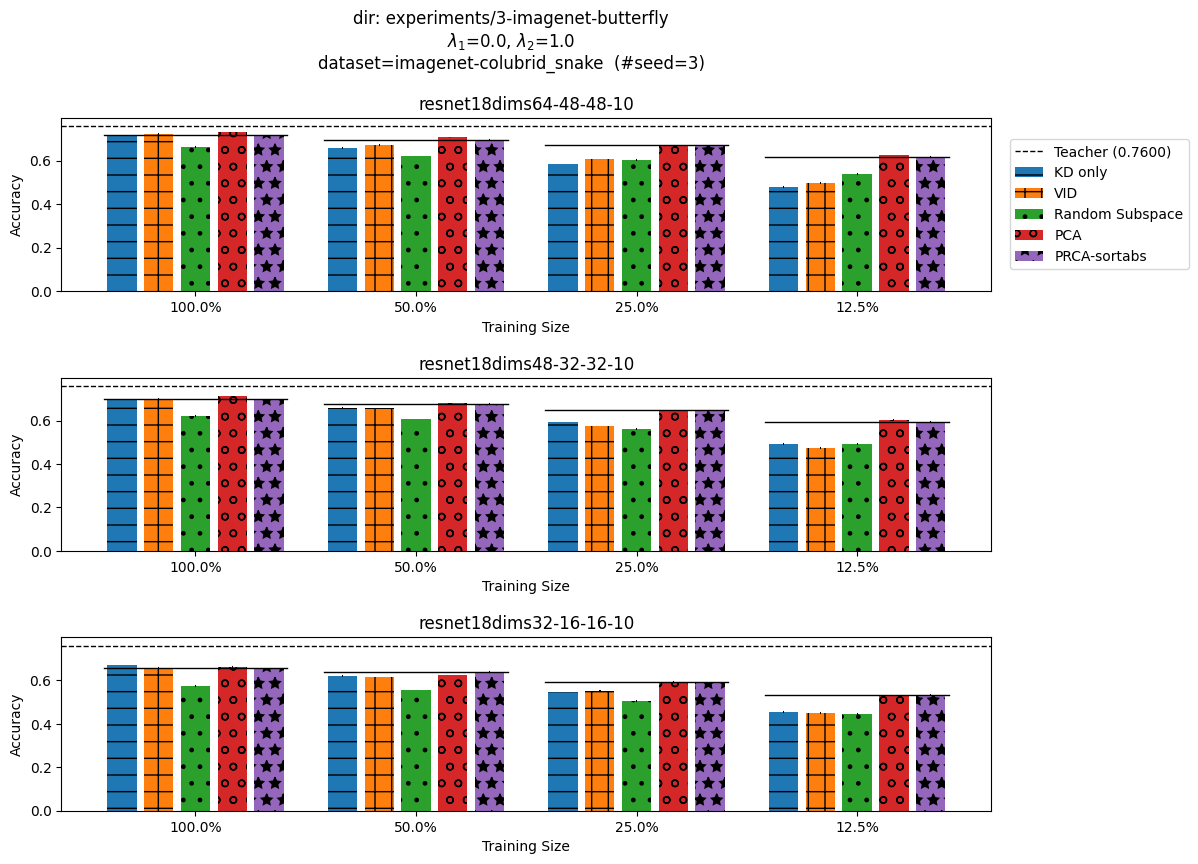

In [213]:
viz_distillation_v2(
    teacher="imagenet-resnet18-tv",
    dataset="imagenet-colubrid_snake",
    arr_students=[
        "resnet18dims64-48-48-10",
        "resnet18dims48-32-32-10",
        "resnet18dims32-16-16-10",

    ],
    arr_training_size=[
        1.0,
        0.5,
        0.25,
        0.125
    ],
    arr_policies = [ 
        "nothing",
        "vid",
        "basis-identity:random--uncentered",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
    ],
)

# Summary (to write)


*Conclusion:*
...

In [194]:
12.5 / 2

6.25